In [1]:
# 03 Modélisation => 4 scénarios × n modèles
# Projet : Telemed Urgence IA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report
)

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✅ Imports OK")

✅ Imports OK


In [2]:
# 02 Chargement des scénarios et labels
# chargement des 4 scénarios préparés dans le notebook preprocessing
scenarios = joblib.load('../data/processed/scenarios.joblib')
y_train, y_test = joblib.load('../data/processed/labels.joblib')

print("✅ Scénarios chargés :")
for name, s in scenarios.items():
    print(f"   • {name:25s} : train={s['X_train'].shape} / test={s['X_test'].shape}")

print(f"\n✅ Labels :")
print(f"   • y_train : {len(y_train)} — distribution : {dict(y_train.value_counts().sort_index())}")
print(f"   • y_test  : {len(y_test)}  — distribution : {dict(y_test.value_counts().sort_index())}")

✅ Scénarios chargés :
   • S1_multimodal             : train=(8064, 583) / test=(2016, 583)
   • S2_sans_sensibles         : train=(8064, 578) / test=(2016, 578)
   • S3_nlp_seul               : train=(8064, 570) / test=(2016, 570)
   • S4_tabulaire_seul         : train=(8064, 5) / test=(2016, 5)

✅ Labels :
   • y_train : 8064 — distribution : {0: np.int64(4042), 1: np.int64(2841), 2: np.int64(1181)}
   • y_test  : 2016  — distribution : {0: np.int64(1011), 1: np.int64(710), 2: np.int64(295)}


In [3]:
# 03 Définition des modèles et fonctions d'évaluation

# Modèles à entraîner
# class_weight='balanced': compense automatiquement le déséquilibre
# en donnant plus de poids aux classes minoritaires (surtout classe 2)
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128),
        max_iter=300,
        random_state=42
    )
}

# fonction d'évaluation
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, scenario_name):
    """
    Entraîne un modèle et retourne toutes les métriques clés
    Priorité sur le recall de la classe 2 (urgence vitale)
    """
    # entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # métriques globales
    acc        = accuracy_score(y_test, y_pred)
    f1         = f1_score(y_test, y_pred, average='weighted')
    recall_c2  = recall_score(y_test, y_pred, labels=[2], average=None)[0]
    recall_all = recall_score(y_test, y_pred, average=None)

    return {
        'scenario'  : scenario_name,
        'model'     : model_name,
        'accuracy'  : round(acc, 4),
        'f1_weighted': round(f1, 4),
        'recall_c0' : round(recall_all[0], 4),
        'recall_c1' : round(recall_all[1], 4),
        'recall_c2' : round(recall_c2, 4),  # ⚠️ métrique prioritaire
        'y_pred'    : y_pred
    }

print("✅ Modèles définis :")
for name in models:
    print(f"   • {name}")

print(f"\n✅ Fonction d'évaluation prête")
print(f"   ⚠️  Métrique prioritaire : Recall classe 2 (urgence vitale)")

✅ Modèles définis :
   • LogisticRegression
   • RandomForest
   • XGBoost
   • LightGBM
   • MLP

✅ Fonction d'évaluation prête
   ⚠️  Métrique prioritaire : Recall classe 2 (urgence vitale)


In [4]:
# 04 Entraînement de tous les modèles sur les 4 scénarios

import copy
results = [] # stocke tous les résultats

for scenario_name, scenario_data in scenarios.items():
    print(f"\n{'='*55}")
    print(f"🔄 Scénario : {scenario_name}")
    print(f"{'='*55}")

    X_tr = scenario_data['X_train']
    X_te = scenario_data['X_test']
    
    for model_name, model in models.items():
        print(f"  ⏳ {model_name}...", end=' ')

        # copie du modèle pour éviter les interférences entre scénarios
        model_copy = copy.deepcopy(model)

        result = evaluate_model(
            model_copy,
            X_tr, X_te,
            y_train, y_test,
            model_name, scenario_name
        )
        results.append(result)

        print(f"acc={result['accuracy']:.3f} | f1={result['f1_weighted']:.3f} | recall_c2={result['recall_c2']:.3f} ✅")

print(f"\n🎉 Entraînement terminé ! {len(results)} expériences au total.")


🔄 Scénario : S1_multimodal
   ⏳ LogisticRegression... acc=0.949 | f1=0.949 | recall_c2=0.932 ✅
   ⏳ RandomForest... acc=0.941 | f1=0.940 | recall_c2=0.908 ✅
   ⏳ XGBoost... acc=0.955 | f1=0.955 | recall_c2=0.898 ✅
   ⏳ LightGBM... acc=0.953 | f1=0.953 | recall_c2=0.908 ✅
   ⏳ MLP... acc=0.944 | f1=0.944 | recall_c2=0.885 ✅

🔄 Scénario : S2_sans_sensibles
   ⏳ LogisticRegression... acc=0.948 | f1=0.948 | recall_c2=0.932 ✅
   ⏳ RandomForest... acc=0.944 | f1=0.944 | recall_c2=0.908 ✅
   ⏳ XGBoost... acc=0.955 | f1=0.955 | recall_c2=0.902 ✅
   ⏳ LightGBM... acc=0.950 | f1=0.950 | recall_c2=0.905 ✅
   ⏳ MLP... acc=0.944 | f1=0.944 | recall_c2=0.895 ✅

🔄 Scénario : S3_nlp_seul
   ⏳ LogisticRegression... acc=0.911 | f1=0.912 | recall_c2=0.908 ✅
   ⏳ RandomForest... acc=0.911 | f1=0.912 | recall_c2=0.915 ✅
   ⏳ XGBoost... acc=0.911 | f1=0.912 | recall_c2=0.908 ✅
   ⏳ LightGBM... acc=0.911 | f1=0.912 | recall_c2=0.915 ✅
   ⏳ MLP... acc=0.911 | f1=0.912 | recall_c2=0.908 ✅

🔄 Scénario : S4_tab

In [5]:
# 05 Tableau comparatif des résultats

# construction du DataFrame de résultats (sans y_pred)
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in results
])

# affichage par scénario
for scenario in df_results['scenario'].unique():
    print(f"\n{'='*65}")
    print(f"📊 {scenario}")
    print(f"{'='*65}")
    sub = df_results[df_results['scenario'] == scenario].drop(columns='scenario')
    sub = sub.sort_values('recall_c2', ascending=False).reset_index(drop=True)
    print(sub.to_string(index=False))

# meilleur modèle global sur recall_c2
print(f"\n{'='*65}")
best = df_results.loc[df_results['recall_c2'].idxmax()]
print(f"🏆 MEILLEUR RECALL CLASSE 2 :")
print(f"   Modèle   : {best['model']}")
print(f"   Scénario : {best['scenario']}")
print(f"   Recall c2: {best['recall_c2']}")
print(f"   F1       : {best['f1_weighted']}")
print(f"   Accuracy : {best['accuracy']}")


📊 S1_multimodal
             model  accuracy  f1_weighted  recall_c0  recall_c1  recall_c2
LogisticRegression    0.9494       0.9492     0.9802     0.9127     0.9322
      RandomForest    0.9405       0.9404     0.9683     0.9141     0.9085
          LightGBM    0.9534       0.9532     0.9812     0.9324     0.9085
           XGBoost    0.9549       0.9547     0.9822     0.9394     0.8983
               MLP    0.9444       0.9443     0.9743     0.9268     0.8847

📊 S2_sans_sensibles
             model  accuracy  f1_weighted  recall_c0  recall_c1  recall_c2
LogisticRegression    0.9479       0.9477     0.9802     0.9085     0.9322
      RandomForest    0.9439       0.9439     0.9713     0.9197     0.9085
          LightGBM    0.9499       0.9497     0.9792     0.9268     0.9051
           XGBoost    0.9554       0.9552     0.9822     0.9394     0.9017
               MLP    0.9439       0.9437     0.9832     0.9085     0.8949

📊 S3_nlp_seul
             model  accuracy  f1_weighted  reca

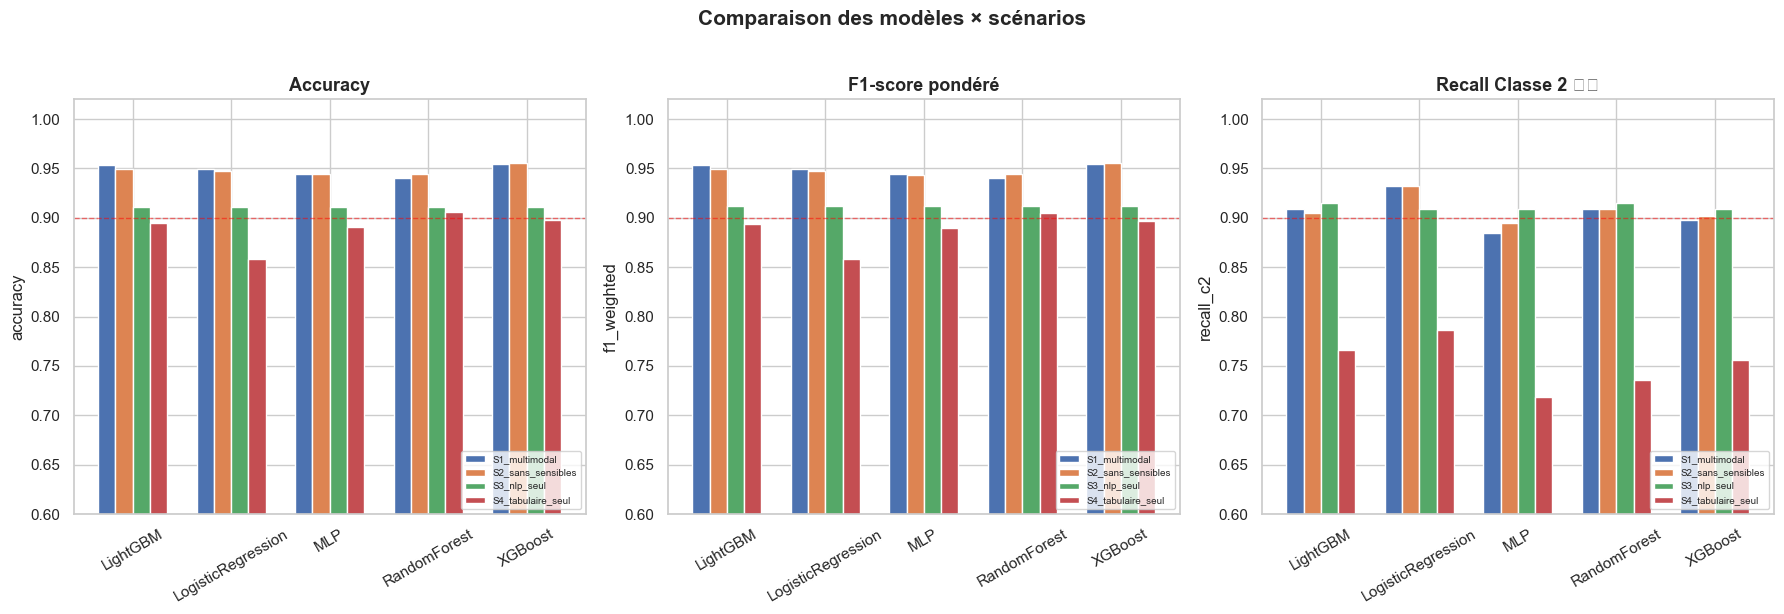

In [6]:
# 06 Visualisation comparative des résultats
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['accuracy', 'f1_weighted', 'recall_c2']
titles  = ['Accuracy', 'F1-score pondéré', 'Recall Classe 2 ⚠️']
colors  = ['#2E75B6', '#2ecc71', '#e74c3c']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    pivot = df_results.pivot(index='model', columns='scenario', values=metric)
    pivot.plot(kind='bar', ax=axes[i], width=0.7, edgecolor='white')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7, loc='lower right')
    axes[i].set_ylim(0.6, 1.02)
    # ligne de référence à 0.90
    axes[i].axhline(y=0.90, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle("Comparaison des modèles × scénarios",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

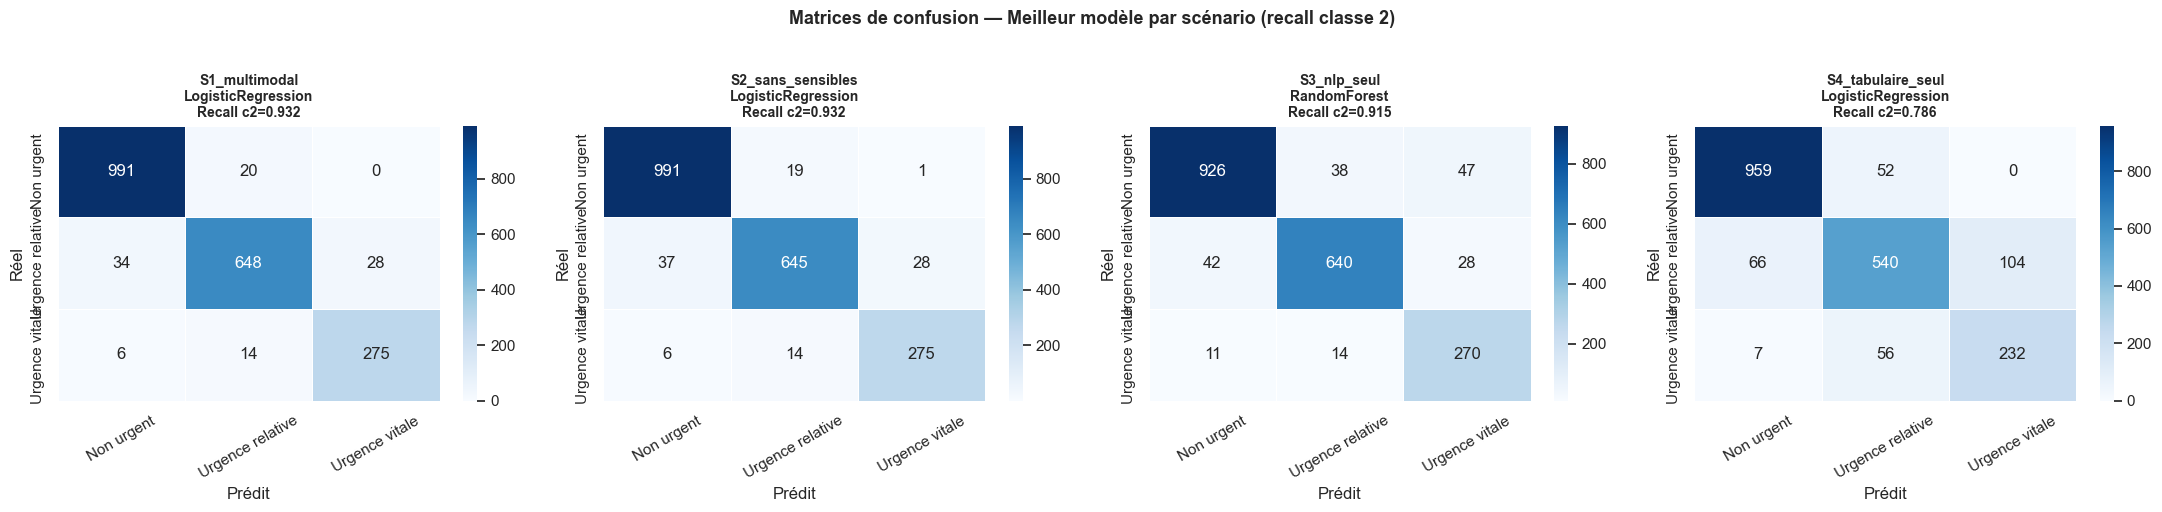

In [ ]:
# 07 - Matrices de confusion — meilleur modèle par scénario

labels_names = ['Non urgent', 'Urgence relative', 'Urgence vitale']
colors_cm = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, scenario_name in enumerate(scenarios.keys()):
    
    # meilleur modèle du scénario selon recall_c2
    best_in_scenario = df_results[df_results['scenario'] == scenario_name]\
                        .sort_values('recall_c2', ascending=False)\
                        .iloc[0]
    
    # récupérer y_pred correspondant
    y_pred = next(r['y_pred'] for r in results 
                  if r['scenario'] == scenario_name 
                  and r['model'] == best_in_scenario['model'])
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues',
        xticklabels=labels_names,
        yticklabels=labels_names,
        ax=axes[i],
        linewidths=0.5
    )
    axes[i].set_title(
        f"{scenario_name}\n{best_in_scenario['model']}\nRecall c2={best_in_scenario['recall_c2']:.3f}",
        fontsize=10, fontweight='bold'
    )
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle("Matrices de confusion — Meilleur modèle par scénario (recall classe 2)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# 08 Validation croisée — meilleur modèle (LogReg S1)

from sklearn.metrics import make_scorer

# scorer personnalisé: recall de la classe 2
recall_c2_scorer = make_scorer(recall_score, labels=[2], average=None)

# meilleur modèle identifié: LogisticRegression sur S1
best_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# StratifiedKFold: garantit la proportion des classes dans chaque fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Validation croisée en cours (5 folds)...")

cv_results = cross_validate(
    best_model,
    scenarios['S1_multimodal']['X_train'],
    y_train,
    cv=skf,
    scoring={
        'accuracy'   : 'accuracy',
        'f1_weighted': 'f1_weighted',
        'recall_c2'  : recall_c2_scorer
    },
    return_train_score=False,
    n_jobs=-1
)

print("✅ Validation croisée terminée !\n")
print(f"{'Métrique':<20} {'Moyenne':>10} {'Écart-type':>12}")
print("-" * 44)
print(f"{'Accuracy':<20} {cv_results['test_accuracy'].mean():>10.4f} {cv_results['test_accuracy'].std():>12.4f}")
print(f"{'F1 weighted':<20} {cv_results['test_f1_weighted'].mean():>10.4f} {cv_results['test_f1_weighted'].std():>12.4f}")
print(f"{'Recall classe 2':<20} {cv_results['test_recall_c2'].mean():>10.4f} {cv_results['test_recall_c2'].std():>12.4f}")

print(f"\n Un écart-type faible = modèle stable et robuste")

⏳ Validation croisée en cours (5 folds)...
✅ Validation croisée terminée !

Métrique                Moyenne   Écart-type
--------------------------------------------
Accuracy                 0.9459       0.0038
F1 weighted              0.9461       0.0039
Recall classe 2          0.9297       0.0158

 Un écart-type faible = modèle stable et robuste


In [9]:
# 09 Logging MLflow

mlflow.set_tracking_uri("../mlflow")
mlflow.set_experiment("telemed-urgence-ia")

print("Logging des expériences dans MLflow...")

for result in results:
    with mlflow.start_run(run_name=f"{result['scenario']}__{result['model']}"):
        
        # tags
        mlflow.set_tag("scenario", result['scenario'])
        mlflow.set_tag("model", result['model'])
        
        # metrics
        mlflow.log_metric("accuracy",    result['accuracy'])
        mlflow.log_metric("f1_weighted", result['f1_weighted'])
        mlflow.log_metric("recall_c0",   result['recall_c0'])
        mlflow.log_metric("recall_c1",   result['recall_c1'])
        mlflow.log_metric("recall_c2",   result['recall_c2'])

# logging séparé pour la validation croisée du meilleur modèle
with mlflow.start_run(run_name="BEST__LogReg_S1_CrossVal"):
    mlflow.set_tag("model", "LogisticRegression")
    mlflow.set_tag("scenario", "S1_multimodal")
    mlflow.set_tag("type", "cross_validation")
    mlflow.log_metric("cv_accuracy_mean",  cv_results['test_accuracy'].mean())
    mlflow.log_metric("cv_accuracy_std",   cv_results['test_accuracy'].std())
    mlflow.log_metric("cv_f1_mean",        cv_results['test_f1_weighted'].mean())
    mlflow.log_metric("cv_f1_std",         cv_results['test_f1_weighted'].std())
    mlflow.log_metric("cv_recall_c2_mean", cv_results['test_recall_c2'].mean())
    mlflow.log_metric("cv_recall_c2_std",  cv_results['test_recall_c2'].std())

print(f"✅ {len(results) + 1} runs loggés dans MLflow !")
print(f"\n Pour visualiser :")
print(f"   cd telemed-urgence-ia && mlflow ui --backend-store-uri mlflow/")

2026/05/30 16:02:47 INFO mlflow.tracking.fluent: Experiment with name 'telemed-urgence-ia' does not exist. Creating a new experiment.


Logging des expériences dans MLflow...
✅ 21 runs loggés dans MLflow !

 Pour visualiser :
   cd telemed-urgence-ia && mlflow ui --backend-store-uri mlflow/


In [11]:
# 10 sauvegarde du meilleur modèle
import os
import copy

# réentraînement du meilleur modèle sur le train complet
best_final_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

best_final_model.fit(
    scenarios['S1_multimodal']['X_train'],
    y_train
)

# sauvegarde du modèle
os.makedirs('../src/models', exist_ok=True)
joblib.dump(best_final_model, '../src/models/best_model.joblib')

# logging MLflow du modèle final
with mlflow.start_run(run_name="FINAL__LogReg_S1_best_model"):
    mlflow.set_tag("model", "LogisticRegression")
    mlflow.set_tag("scenario", "S1_multimodal")
    mlflow.set_tag("type", "final_model")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("accuracy",    0.9494)
    mlflow.log_metric("f1_weighted", 0.9492)
    mlflow.log_metric("recall_c2",   0.9322)
    mlflow.sklearn.log_model(best_final_model, "model")

print("✅ Meilleur modèle sauvegardé :")
print("   • src/models/best_model.joblib")
print("   • MLflow run : FINAL__LogReg_S1_best_model")
print(f"\n Récapitulatif :")
print(f"   Modèle   : LogisticRegression (class_weight='balanced')")
print(f"   Scénario : S1 Multimodal complet")
print(f"   Accuracy : 94.94%")
print(f"   F1       : 94.92%")
print(f"   Recall c2: 93.22% ⚠️")

2026/05/30 16:19:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 16:19:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Meilleur modèle sauvegardé :
   • src/models/best_model.joblib
   • MLflow run : FINAL__LogReg_S1_best_model

 Récapitulatif :
   Modèle   : LogisticRegression (class_weight='balanced')
   Scénario : S1 Multimodal complet
   Accuracy : 94.94%
   F1       : 94.92%
   Recall c2: 93.22% ⚠️
